In [1]:
%%bash
wget -q https://developer.nvidia.com/downloads/assets/tools/secure/nsight-systems/2024_1/nsight-systems-2024.1.1_2024.1.1.59-1_amd64.deb
dpkg -i nsight-systems-2024.1.1_2024.1.1.59-1_amd64.deb


Selecting previously unselected package nsight-systems-2024.1.1.
(Reading database ... 125128 files and directories currently installed.)
Preparing to unpack nsight-systems-2024.1.1_2024.1.1.59-1_amd64.deb ...
Unpacking nsight-systems-2024.1.1 (2024.1.1.59-241133802077v0) ...
Processing triggers for mailcap (3.70+nmu1ubuntu1) ...


dpkg: dependency problems prevent configuration of nsight-systems-2024.1.1:
 nsight-systems-2024.1.1 depends on libtinfo5; however:
  Package libtinfo5 is not installed.
 nsight-systems-2024.1.1 depends on libxcb-xinerama0; however:
  Package libxcb-xinerama0 is not installed.
 nsight-systems-2024.1.1 depends on libxcb-icccm4; however:
  Package libxcb-icccm4 is not installed.
 nsight-systems-2024.1.1 depends on libxcb-image0; however:
  Package libxcb-image0 is not installed.
 nsight-systems-2024.1.1 depends on libxcb-keysyms1; however:
  Package libxcb-keysyms1 is not installed.
 nsight-systems-2024.1.1 depends on libxcb-render-util0; however:
  Package libxcb-render-util0 is not installed.
 nsight-systems-2024.1.1 depends on libxkbcommon-x11-0; however:
  Package libxkbcommon-x11-0 is not installed.
 nsight-systems-2024.1.1 depends on libxcb-xinput0; however:
  Package libxcb-xinput0 is not installed.
 nsight-systems-2024.1.1 depends on libxcb-cursor0; however:
  Package libxcb-curs

CalledProcessError: Command 'b'wget -q https://developer.nvidia.com/downloads/assets/tools/secure/nsight-systems/2024_1/nsight-systems-2024.1.1_2024.1.1.59-1_amd64.deb\ndpkg -i nsight-systems-2024.1.1_2024.1.1.59-1_amd64.deb\n'' returned non-zero exit status 1.

In [2]:
import os
os.environ["PATH"] += ":/opt/nvidia/nsight-systems/2024.1.1/bin"
os.environ["PATH"] += ":/opt/nvidia/nsight-compute/2025.1.1/target-linux-x64"

!nsys --version
!ncu --version

NVIDIA Nsight Systems version 2024.1.1.59-241133802077v0
NVIDIA (R) Nsight Compute Command Line Profiler
Copyright (c) 2018-2025 NVIDIA Corporation
Version 2025.1.1.0 (build 35528883) (public-release)


# on the GPU

## the custom kernels

In [12]:
import cupy as cp
import numpy as np

cuda_source = r"""
extern "C" __global__
void histogram_vec4(
    const unsigned char* __restrict__ image,
    unsigned int*        __restrict__ hist,
    const int                         n_pixels)
{
    __shared__ unsigned int smem_hist[256];

    for (int i = threadIdx.x; i < 256; i += blockDim.x)
        smem_hist[i] = 0u;
    __syncthreads();

    // reinterpret the byte array as uint32 — each element = 4 packed pixels
    const unsigned int* image4 = reinterpret_cast<const unsigned int*>(image);
    int n_vec  = n_pixels / 4;
    int idx    = blockIdx.x * blockDim.x + threadIdx.x;
    int stride = blockDim.x * gridDim.x;

    while (idx < n_vec) {
        unsigned int pack = image4[idx];   // one 32-bit load = 4 pixels

        atomicAdd(&smem_hist[ pack        & 0xFF], 1u);
        atomicAdd(&smem_hist[(pack >>  8) & 0xFF], 1u);
        atomicAdd(&smem_hist[(pack >> 16) & 0xFF], 1u);
        atomicAdd(&smem_hist[(pack >> 24) & 0xFF], 1u);

        idx += stride;
    }

    // tail: handle remaining pixels when n_pixels is not divisible by 4
    int tail_start = n_vec * 4;
    int tail_idx   = tail_start + blockIdx.x * blockDim.x + threadIdx.x;
    if (tail_idx < n_pixels)
        atomicAdd(&smem_hist[image[tail_idx]], 1u);

    __syncthreads();
    for (int i = threadIdx.x; i < 256; i += blockDim.x)
        atomicAdd(&hist[i], smem_hist[i]);
}

extern "C" __global__
void kogge_stone_scan(
    const unsigned int* __restrict__ hist,
    float*              __restrict__ cdf,
    const int                        n_pixels)
{
    __shared__ float smem[256];
    int tid = threadIdx.x;
    smem[tid] = (float)hist[tid] / (float)n_pixels;
    __syncthreads();

    #pragma unroll
    for (int d = 0; d < 8; d++) {
        int stride = 1 << d;
        float val = smem[tid];
        if (tid >= stride)
            val += smem[tid - stride];
        __syncthreads();
        smem[tid] = val;
        __syncthreads();
    }
    cdf[tid] = smem[tid];
}

extern "C" __global__
void lut_apply_textbook(
    const unsigned char* __restrict__ image_in,
    unsigned char*       __restrict__ image_out,
    const float*         __restrict__ cdf,
    const float                        cdf_min,
    const int                          n_pixels)
{
    int idx    = blockIdx.x * blockDim.x + threadIdx.x;
    int stride = blockDim.x * gridDim.x;
    while (idx < n_pixels) {
        float mapped = (cdf[image_in[idx]] - cdf_min) / (1.0f - cdf_min);
        mapped = fminf(1.0f, fmaxf(0.0f, mapped));
        image_out[idx] = (unsigned char)__float2uint_rn(mapped * 255.0f);
        idx += stride;
    }
}

extern "C" __global__
void histogram_ballot(
    const unsigned char* __restrict__ image,
    unsigned int*        __restrict__ hist,
    const int                         n_pixels)
{
    __shared__ unsigned int smem_hist[256];

    for (int i = threadIdx.x; i < 256; i += blockDim.x)
        smem_hist[i] = 0u;
    __syncthreads();

    int idx    = blockIdx.x * blockDim.x + threadIdx.x;
    int stride = blockDim.x * gridDim.x;
    int lane   = threadIdx.x & 31;   // which of the 32 lanes am I? [0,31]

    while (idx < n_pixels) {
        unsigned char val = image[idx];

        // __match_any_sync(mask, val):
        //   looks at all active lanes in the warp (mask=0xFFFFFFFF = all 32)
        //   returns a bitmask where bit k is set if lane k has the same val
        //   as the calling thread.
        //   this is ONE warp instruction — all 32 lanes execute it together.
        unsigned mask = __activemask();
        unsigned int peers =
            __match_any_sync(mask, (unsigned int)val);
        

        // peers & ((1<<lane)-1) isolates bits from lanes BELOW mine.
        // if this is zero, I am the lowest-numbered lane with this value.
        // only the lowest lane does the atomic — adding the total peer count.
        bool is_leader = (peers & ((1u << lane) - 1u)) == 0u;
        if (is_leader)
            atomicAdd(&smem_hist[val], __popc(peers));
            // __popc = population count = number of 1-bits = number of peers

        idx += stride;
    }

    __syncthreads();
    for (int i = threadIdx.x; i < 256; i += blockDim.x)
        atomicAdd(&hist[i], smem_hist[i]);
}

// ─── Fix 2+3 combined ────────────────────────────────────────────────────────
extern "C" __global__

void histogram_vec4_ballot(
    const unsigned char* __restrict__ image,
    unsigned int*        __restrict__ hist,
    const int            n_pixels)
{
    __shared__ unsigned int smem_hist[256];

    for (int i = threadIdx.x; i < 256; i += blockDim.x)
        smem_hist[i] = 0;
    __syncthreads();

    const unsigned int* image4 =
        reinterpret_cast<const unsigned int*>(image);

    int n_vec  = n_pixels / 4;
    int idx    = blockIdx.x * blockDim.x + threadIdx.x;
    int stride = blockDim.x * gridDim.x;
    int lane   = threadIdx.x & 31;

    while (idx < n_vec)
    {
        unsigned int pack = image4[idx];

        unsigned char vals[4];
        vals[0] =  pack        & 0xFF;
        vals[1] = (pack >>  8) & 0xFF;
        vals[2] = (pack >> 16) & 0xFF;
        vals[3] = (pack >> 24) & 0xFF;

        #pragma unroll
        for (int k = 0; k < 4; k++)
        {
            unsigned char val = vals[k];

            unsigned mask  = __activemask();
            unsigned peers = __match_any_sync(mask,
                                              (unsigned int)val);

            bool leader =
                (peers & ((1u << lane) - 1u)) == 0u;

            if (leader)
                atomicAdd(&smem_hist[val], __popc(peers));
        }

        idx += stride;
    }

    __syncthreads();

    for (int i = threadIdx.x; i < 256; i += blockDim.x)
        atomicAdd(&hist[i], smem_hist[i]);
}

// ─── original baseline (for fair same-run comparison) ────────────────────────
extern "C" __global__
void histogram_baseline(
    const unsigned char* __restrict__ image,
    unsigned int*        __restrict__ hist,
    const int                         n_pixels)
{
    __shared__ unsigned int smem_hist[256];
    for (int i = threadIdx.x; i < 256; i += blockDim.x)
        smem_hist[i] = 0u;
    __syncthreads();

    int idx    = blockIdx.x * blockDim.x + threadIdx.x;
    int stride = blockDim.x * gridDim.x;
    while (idx < n_pixels) {
        atomicAdd(&smem_hist[image[idx]], 1u);
        idx += stride;
    }
    __syncthreads();

    for (int i = threadIdx.x; i < 256; i += blockDim.x)
        atomicAdd(&hist[i], smem_hist[i]);
}

"""

In [ ]:
cuda_source_multi = r"""
template <int L>
__global__ void histogram_vec4_L(
    const unsigned char* __restrict__ image,
    unsigned int*        __restrict__ hist,
    const int                         n_pixels)
{
    __shared__ unsigned int smem_hist[L];

    for (int i = threadIdx.x; i < L; i += blockDim.x)
        smem_hist[i] = 0u;
    __syncthreads();

    int idx    = blockIdx.x * blockDim.x + threadIdx.x;
    int stride = blockDim.x * gridDim.x;
    while (idx < n_pixels) {
        unsigned int pixel = image[idx];
        unsigned int bin = (pixel * L) >> 8;
        atomicAdd(&smem_hist[bin], 1u);
        idx += stride;
    }
    __syncthreads();

    for (int i = threadIdx.x; i < L; i += blockDim.x)
        atomicAdd(&hist[i], smem_hist[i]);
}

extern "C" __global__
void histogram_L256(const unsigned char* img, unsigned int* hist, int n)
{ histogram_vec4_L<256>(img, hist, n); }

extern "C" __global__
void histogram_L512(const unsigned char* img, unsigned int* hist, int n)
{ histogram_vec4_L<512>(img, hist, n); }

extern "C" __global__
void histogram_L1024(const unsigned char* img, unsigned int* hist, int n)
{ histogram_vec4_L<1024>(img, hist, n); }

extern "C" __global__
void histogram_L4096(const unsigned char* img, unsigned int* hist, int n)
{ histogram_vec4_L<4096>(img, hist, n); }
"""

## comparing different bin sizes
## histogram_vec4 used

In [ ]:
# ── compile ──────────────────────────────────────────────────────────────────
module_single = cp.RawModule(code=cuda_source)
hist_kernel   = module_single.get_function("histogram_vec4")
scan_kernel   = module_single.get_function("kogge_stone_scan")
lut_kernel    = module_single.get_function("lut_apply_textbook")

module_multi  = cp.RawModule(code=cuda_source_multi, options=('--std=c++14',))

# ── single-run correctness check ─────────────────────────────────────────────
rng      = np.random.default_rng(42)
img_np   = rng.integers(60, 180, size=(1080, 1920), dtype=np.uint8)
n_pixels = img_np.size
T = 256
B = (n_pixels + T - 1) // T

img_d     = cp.asarray(img_np.ravel())
img_out_d = cp.zeros(n_pixels, dtype=cp.uint8)
hist_d    = cp.zeros(256, dtype=cp.uint32)
cdf_d     = cp.zeros(256, dtype=cp.float32)

hist_kernel((B,), (T,), (img_d, hist_d, n_pixels))
scan_kernel((1,), (256,), (hist_d, cdf_d, n_pixels))
cdf_min = float(cdf_d[cdf_d > 0][0])
lut_kernel((B,), (T,), (img_d, img_out_d, cdf_d, np.float32(cdf_min), n_pixels))
cp.cuda.Stream.null.synchronize()

img_out = cp.asnumpy(img_out_d).reshape(1080, 1920)
assert abs(float(cp.sum(cdf_d[-1:])) - 1.0) < 1e-4, "CDF does not end at 1.0"
print(f"Input  range : [{img_np.min()}, {img_np.max()}]")
print(f"Output range : [{img_out.min()}, {img_out.max()}]")
print(f"Input  std   : {img_np.std():.2f}")
print(f"Output std   : {img_out.std():.2f}")

# ── multi-bin contention sweep ────────────────────────────────────────────────
img_np2 = rng.integers(0, 256, size=(1080, 1920), dtype=np.uint8)
img_d2  = cp.asarray(img_np2.ravel())

configs = [
    (256,  'histogram_L256'),
    (512,  'histogram_L512'),
    (1024, 'histogram_L1024'),
    (4096, 'histogram_L4096'),
]

print(
    f"\n{'L':>6} "
    f"{'occ %':>10} "
    f"{'smem/block':>12} "
    f"{'time (ns)':>12} "
    f"{'eff BW':>12}"
)
print("-" * 60)

for L, fname in configs:

    kern = module_multi.get_function(fname)

    # occupancy estimate
    smem_per_block = L * 4
    
    blocks_from_smem = 65536 // smem_per_block
    blocks_from_threads = 2048 // T
    
    blocks_per_sm = min(
        blocks_from_smem,
        blocks_from_threads,
        16
    )
    

    occupancy = (blocks_per_sm * T) / 2048.0

    hist_d = cp.zeros(L, dtype=cp.uint32)

    # warmup
    kern((B,), (T,), (img_d2, hist_d, n_pixels))
    cp.cuda.Stream.null.synchronize()

    hist_d.fill(0)

    # timed run
    t0 = cp.cuda.Event()
    t1 = cp.cuda.Event()

    t0.record()
    kern((B,), (T,), (img_d2, hist_d, n_pixels))
    t1.record()
    t1.synchronize()

    ms = cp.cuda.get_elapsed_time(t0, t1)

    ns = ms * 1e6
    eff_bw = (n_pixels) / (ms * 1e-3) / 1e9

    smem = L * 4

    print(
        f"{L:>6} "
        f"{occupancy*100:>9.1f}% "
        f"{smem:>10} B "
        f"{ns:>12.0f} "
        f"{eff_bw:>12.2f}"
    )

    assert int(cp.sum(hist_d)) == n_pixels

print(hasattr(cp.cuda.driver,
              "occupancyMaxActiveBlocksPerMultiprocessor"))

In [6]:
!nsys profile \
    --trace=cuda,nvtx,osrt \
    --output=/kaggle/working/histeq_gpu \
    --force-overwrite=true \
    python /kaggle/working/run_histeq.py

Generating '/tmp/nsys-report-11d4.qdstrm'
[1/1] [========================100%] histeq_gpu.nsys-rep
Generated:
    /kaggle/working/histeq_gpu.nsys-rep


## checking SM assignment

In [8]:
sm_instrumentation = r"""
extern "C" __global__
void record_sm_ids(unsigned int* sm_ids, int n_blocks)
{
    if (threadIdx.x == 0) {
        unsigned int smid;
        asm volatile("mov.u32 %0, %smid;" : "=r"(smid));
        sm_ids[blockIdx.x] = smid;
    }
}

extern "C" __global__
void histogram_instrumented(
    const unsigned char* __restrict__ image,
    unsigned int*        __restrict__ hist,
    unsigned int*        __restrict__ sm_ids,
    unsigned int*        __restrict__ block_order,
    const int                         n_pixels)
{
    __shared__ unsigned int smem_hist[256];

    if (threadIdx.x == 0) {
        unsigned int smid;
        asm volatile("mov.u32 %0, %smid;" : "=r"(smid));
        sm_ids[blockIdx.x] = smid;
        block_order[blockIdx.x] = atomicAdd(&block_order[gridDim.x], 1u);
    }

    for (int i = threadIdx.x; i < 256; i += blockDim.x)
        smem_hist[i] = 0u;
    __syncthreads();

    int idx    = blockIdx.x * blockDim.x + threadIdx.x;
    int stride = blockDim.x * gridDim.x;
    while (idx < n_pixels) {
        atomicAdd(&smem_hist[image[idx]], 1u);
        idx += stride;
    }
    __syncthreads();

    for (int i = threadIdx.x; i < 256; i += blockDim.x)
        atomicAdd(&hist[i], smem_hist[i]);
}
"""

mod        = cp.RawModule(code=sm_instrumentation)
kern_smid  = mod.get_function("record_sm_ids")
kern_instr = mod.get_function("histogram_instrumented")

rng      = np.random.default_rng(42)
img_np   = rng.integers(0, 256, size=(1080, 1920), dtype=np.uint8)
n_pixels = img_np.size
T = 256
B = (n_pixels + T - 1) // T   # 8100

img_d         = cp.asarray(img_np.ravel())
hist_d        = cp.zeros(256,    dtype=cp.uint32)
sm_ids_d      = cp.zeros(B,      dtype=cp.uint32)
block_order_d = cp.zeros(B + 1,  dtype=cp.uint32)   # last slot = atomic counter

# warmup
kern_instr((B,), (T,), (img_d, hist_d, sm_ids_d, block_order_d, n_pixels))
cp.cuda.Stream.null.synchronize()
hist_d.fill(0); sm_ids_d.fill(0); block_order_d.fill(0)

# profiled run
kern_instr((B,), (T,), (img_d, hist_d, sm_ids_d, block_order_d, n_pixels))
cp.cuda.Stream.null.synchronize()

sm_ids      = cp.asnumpy(sm_ids_d)
block_order = cp.asnumpy(block_order_d[:B])
hist_cpu    = cp.asnumpy(hist_d)

assert hist_cpu.sum() == n_pixels, "histogram sum mismatch"

unique_sms, counts = np.unique(sm_ids, return_counts=True)
sort_idx           = np.argsort(counts)[::-1]

print(f"Total blocks launched : {B}")
print(f"Unique SMs used       : {len(unique_sms)} / 40")
print(f"Blocks per SM — min: {counts.min()},  max: {counts.max()},  "
      f"mean: {counts.mean():.1f},  std: {counts.std():.2f}")
print()
print(f"{'SM id':>6}  {'blocks':>8}  {'warps':>8}  {'% of total':>10}")
print("-" * 40)
for i in sort_idx:
    sm   = unique_sms[i]
    blks = counts[i]
    print(f"{sm:>6}  {blks:>8}  {blks*8:>8}  {100.0*blks/B:>9.2f}%")

print()
print("First 40 block arrivals (arrival order → block index → SM):")
order_to_block = np.argsort(block_order)
for rank in range(min(40, B)):
    blk = order_to_block[rank]
    print(f"  [{rank:>3}] block {blk:>5} → SM {sm_ids[blk]:>2}", end="")
    if (rank + 1) % 4 == 0:
        print()

Total blocks launched : 8100
Unique SMs used       : 40 / 40
Blocks per SM — min: 195,  max: 216,  mean: 202.5,  std: 4.33

 SM id    blocks     warps  % of total
----------------------------------------
    22       216      1728       2.67%
    21       210      1680       2.59%
    19       210      1680       2.59%
    24       208      1664       2.57%
    20       208      1664       2.57%
    33       207      1656       2.56%
    26       207      1656       2.56%
    28       206      1648       2.54%
    18       206      1648       2.54%
    30       205      1640       2.53%
    37       205      1640       2.53%
    32       205      1640       2.53%
    38       204      1632       2.52%
    23       204      1632       2.52%
    29       204      1632       2.52%
    27       204      1632       2.52%
    25       203      1624       2.51%
     0       203      1624       2.51%
    36       203      1624       2.51%
    13       202      1616       2.49%
     5       201

## comparing different block sizes
## and different atomic updates

In [30]:
import cupy as cp
import numpy as np

cuda_fixes = r"""
// ─── Fix 2: vectorized loads ─────────────────────────────────────────────────
// Loads 4 pixels per instruction (32-bit load instead of 8-bit load).
// One load stall amortized over 4 atomics instead of 1.

extern "C" __global__
void histogram_vec4(
    const unsigned char* __restrict__ image,
    unsigned int*        __restrict__ hist,
    const int                         n_pixels)
{
    __shared__ unsigned int smem_hist[256];

    for (int i = threadIdx.x; i < 256; i += blockDim.x)
        smem_hist[i] = 0u;
    __syncthreads();

    // reinterpret the byte array as uint32 — each element = 4 packed pixels
    const unsigned int* image4 = reinterpret_cast<const unsigned int*>(image);
    int n_vec  = n_pixels / 4;
    int idx    = blockIdx.x * blockDim.x + threadIdx.x;
    int stride = blockDim.x * gridDim.x;

    while (idx < n_vec) {
        unsigned int pack = image4[idx];   // one 32-bit load = 4 pixels

        atomicAdd(&smem_hist[ pack        & 0xFF], 1u);
        atomicAdd(&smem_hist[(pack >>  8) & 0xFF], 1u);
        atomicAdd(&smem_hist[(pack >> 16) & 0xFF], 1u);
        atomicAdd(&smem_hist[(pack >> 24) & 0xFF], 1u);

        idx += stride;
    }

    // tail: handle remaining pixels when n_pixels is not divisible by 4
    int tail_start = n_vec * 4;
    int tail_idx   = tail_start + blockIdx.x * blockDim.x + threadIdx.x;
    if (tail_idx < n_pixels)
        atomicAdd(&smem_hist[image[tail_idx]], 1u);

    __syncthreads();
    for (int i = threadIdx.x; i < 256; i += blockDim.x)
        atomicAdd(&hist[i], smem_hist[i]);
}

// ─── Fix 3: warp ballot histogram ────────────────────────────────────────────
// Uses __match_any_sync: a single warp instruction that returns a bitmask
// of which lanes share the same value as the calling thread.
// The lowest matching lane does ONE atomic adding the count for all matches.
// Replaces up to 32 atomics with 1 per unique value per warp.

extern "C" __global__
void histogram_ballot(
    const unsigned char* __restrict__ image,
    unsigned int*        __restrict__ hist,
    const int                         n_pixels)
{
    __shared__ unsigned int smem_hist[256];

    for (int i = threadIdx.x; i < 256; i += blockDim.x)
        smem_hist[i] = 0u;
    __syncthreads();

    int idx    = blockIdx.x * blockDim.x + threadIdx.x;
    int stride = blockDim.x * gridDim.x;
    int lane   = threadIdx.x & 31;   // which of the 32 lanes am I? [0,31]

    while (idx < n_pixels) {
        unsigned char val = image[idx];

        // __match_any_sync(mask, val):
        //   looks at all active lanes in the warp (mask=0xFFFFFFFF = all 32)
        //   returns a bitmask where bit k is set if lane k has the same val
        //   as the calling thread.
        //   this is ONE warp instruction — all 32 lanes execute it together.
        unsigned mask = __activemask();
        unsigned int peers =
            __match_any_sync(mask, (unsigned int)val);
        

        // peers & ((1<<lane)-1) isolates bits from lanes BELOW mine.
        // if this is zero, I am the lowest-numbered lane with this value.
        // only the lowest lane does the atomic — adding the total peer count.
        bool is_leader = (peers & ((1u << lane) - 1u)) == 0u;
        if (is_leader)
            atomicAdd(&smem_hist[val], __popc(peers));
            // __popc = population count = number of 1-bits = number of peers

        idx += stride;
    }

    __syncthreads();
    for (int i = threadIdx.x; i < 256; i += blockDim.x)
        atomicAdd(&hist[i], smem_hist[i]);
}

// ─── Fix 2+3 combined ────────────────────────────────────────────────────────
extern "C" __global__

void histogram_vec4_ballot(
    const unsigned char* __restrict__ image,
    unsigned int*        __restrict__ hist,
    const int            n_pixels)
{
    __shared__ unsigned int smem_hist[256];

    for (int i = threadIdx.x; i < 256; i += blockDim.x)
        smem_hist[i] = 0;
    __syncthreads();

    const unsigned int* image4 =
        reinterpret_cast<const unsigned int*>(image);

    int n_vec  = n_pixels / 4;
    int idx    = blockIdx.x * blockDim.x + threadIdx.x;
    int stride = blockDim.x * gridDim.x;
    int lane   = threadIdx.x & 31;

    while (idx < n_vec)
    {
        unsigned int pack = image4[idx];

        unsigned char vals[4];
        vals[0] =  pack        & 0xFF;
        vals[1] = (pack >>  8) & 0xFF;
        vals[2] = (pack >> 16) & 0xFF;
        vals[3] = (pack >> 24) & 0xFF;

        #pragma unroll
        for (int k = 0; k < 4; k++)
        {
            unsigned char val = vals[k];

            unsigned mask  = __activemask();
            unsigned peers = __match_any_sync(mask,
                                              (unsigned int)val);

            bool leader =
                (peers & ((1u << lane) - 1u)) == 0u;

            if (leader)
                atomicAdd(&smem_hist[val], __popc(peers));
        }

        idx += stride;
    }

    __syncthreads();

    for (int i = threadIdx.x; i < 256; i += blockDim.x)
        atomicAdd(&hist[i], smem_hist[i]);
}

// ─── original baseline (for fair same-run comparison) ────────────────────────
extern "C" __global__
void histogram_baseline(
    const unsigned char* __restrict__ image,
    unsigned int*        __restrict__ hist,
    const int                         n_pixels)
{
    __shared__ unsigned int smem_hist[256];
    for (int i = threadIdx.x; i < 256; i += blockDim.x)
        smem_hist[i] = 0u;
    __syncthreads();

    int idx    = blockIdx.x * blockDim.x + threadIdx.x;
    int stride = blockDim.x * gridDim.x;
    while (idx < n_pixels) {
        atomicAdd(&smem_hist[image[idx]], 1u);
        idx += stride;
    }
    __syncthreads();

    for (int i = threadIdx.x; i < 256; i += blockDim.x)
        atomicAdd(&hist[i], smem_hist[i]);
}
"""

# ── compile ───────────────────────────────────────────────────────────────────
mod = cp.RawModule(code=cuda_fixes, options=('--std=c++14',))
kern_baseline     = mod.get_function("histogram_baseline")
kern_vec4         = mod.get_function("histogram_vec4")
kern_ballot       = mod.get_function("histogram_ballot")
kern_vec4_ballot  = mod.get_function("histogram_vec4_ballot")

# ── input ─────────────────────────────────────────────────────────────────────
rng      = np.random.default_rng(42)
img_np   = rng.integers(0, 256, size=(1080, 1920), dtype=np.uint8)
n_pixels = img_np.size   # 2,073,600
img_d    = cp.asarray(img_np.ravel())

T = 512
B = (n_pixels + T - 1) // T   # 8100 blocks

# reference histogram for correctness check
ref = np.bincount(img_np.ravel(), minlength=256).astype(np.uint32)

# ── benchmark loop ────────────────────────────────────────────────────────────
kernels = [
    ("baseline",    kern_baseline),
    ("vec4",        kern_vec4),
    ("ballot",      kern_ballot),
    ("vec4+ballot", kern_vec4_ballot),
]

PEAK_BW = 320.0   # T4 HBM peak GB/s
REPEATS = 10      # average over multiple runs to reduce noise

print(f"{'kernel':>14}  {'avg (ns)':>10}  {'eff BW (GB/s)':>14}  {'η':>6}  {'speedup':>8}  correct")
print("-" * 70)



for T in [128, 256, 512, 1024]:
    baseline_ns = None
    print("T=",T)
    B = (n_pixels + T - 1) // T
    for name, kern in kernels:
        hist_d = cp.zeros(256, dtype=cp.uint32)
    
        # warmup
        kern((B,), (T,), (img_d, hist_d, n_pixels))
        cp.cuda.Stream.null.synchronize()
    
        # timed runs
        times = []
        for _ in range(REPEATS):
            hist_d.fill(0)
            t0 = cp.cuda.Event(); t1 = cp.cuda.Event()
            t0.record()
            kern((B,), (T,), (img_d, hist_d, n_pixels))
            t1.record(); t1.synchronize()
            times.append(cp.cuda.get_elapsed_time(t0, t1) * 1e6)   # ns
    
        avg_ns  = np.mean(times)
        eff_bw  = (n_pixels * 1) / (avg_ns * 1e-9) / 1e9
        eta     = eff_bw / PEAK_BW
        correct = np.array_equal(cp.asnumpy(hist_d), ref)
    
        if baseline_ns is None:
            baseline_ns = avg_ns
        speedup = baseline_ns / avg_ns
    
        print(f"{name:>14}  {avg_ns:>10.0f}  {eff_bw:>14.2f}  {eta:>6.3f}  {speedup:>7.2f}x  {correct}")
        print(np.mean(times))
        print(np.std(times))
        print(np.min(times))
        print(np.max(times))
    print()

        kernel    avg (ns)   eff BW (GB/s)       η   speedup  correct
----------------------------------------------------------------------
T= 128
      baseline      203382           10.20   0.032     1.00x  True
203382.3996782303
2726.1302425194303
200672.0006465912
208895.9962129593
          vec4      393587            5.27   0.016     0.52x  True
393587.201833725
4891.802262905598
390080.0049304962
407584.011554718
        ballot      392112            5.29   0.017     0.52x  True
392111.998796463
1400.6576650495604
390879.9886703491
395296.00739479065
   vec4+ballot      322086            6.44   0.020     0.63x  True
322086.3997936249
1283.5016416757894
320255.99479675293
324992.00105667114

T= 256
      baseline      201712           10.28   0.032     1.00x  True
201711.99887990952
3109.3792260601163
198911.99469566345
209887.99631595612
          vec4      203059           10.21   0.032     0.99x  True
203059.1994524002
6079.683785723193
200576.00736618042
221184.00037288666
 

# on actual images


IMG_1608.JPG
baseline        time = 1.350 ms
vec4            time = 1.385 ms
ballot          time = 1.036 ms


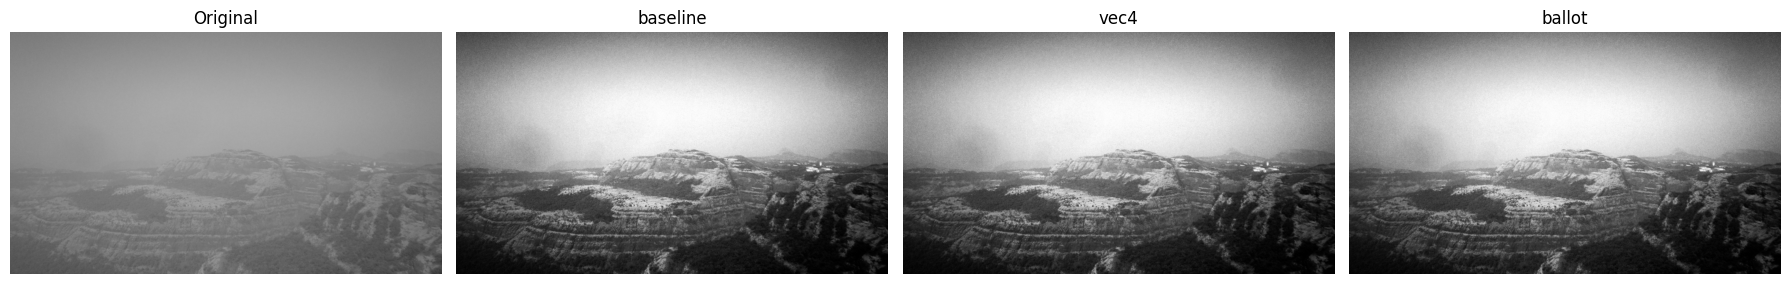

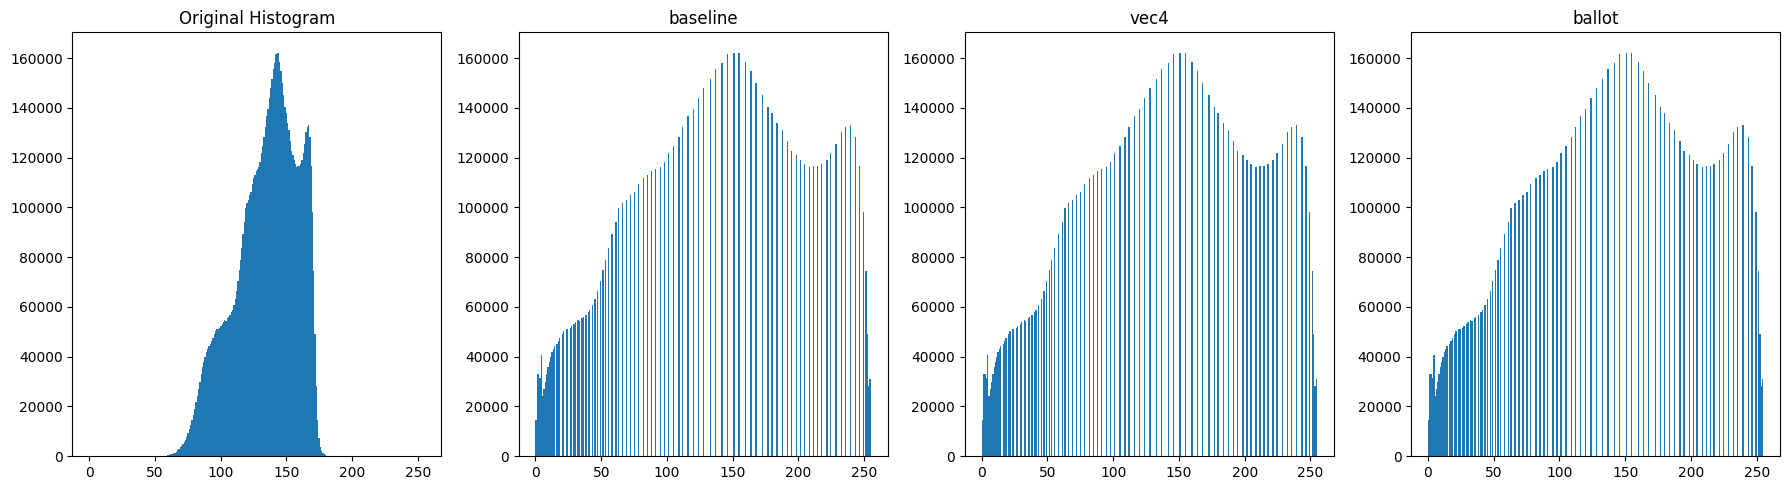


IMG_0043.JPG
baseline        time = 1.366 ms
vec4            time = 1.374 ms
ballot          time = 1.395 ms


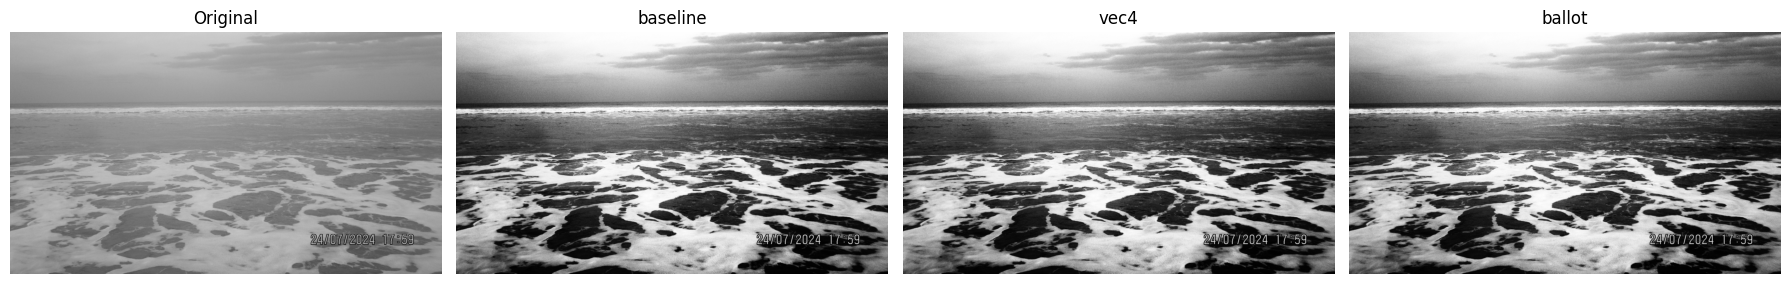

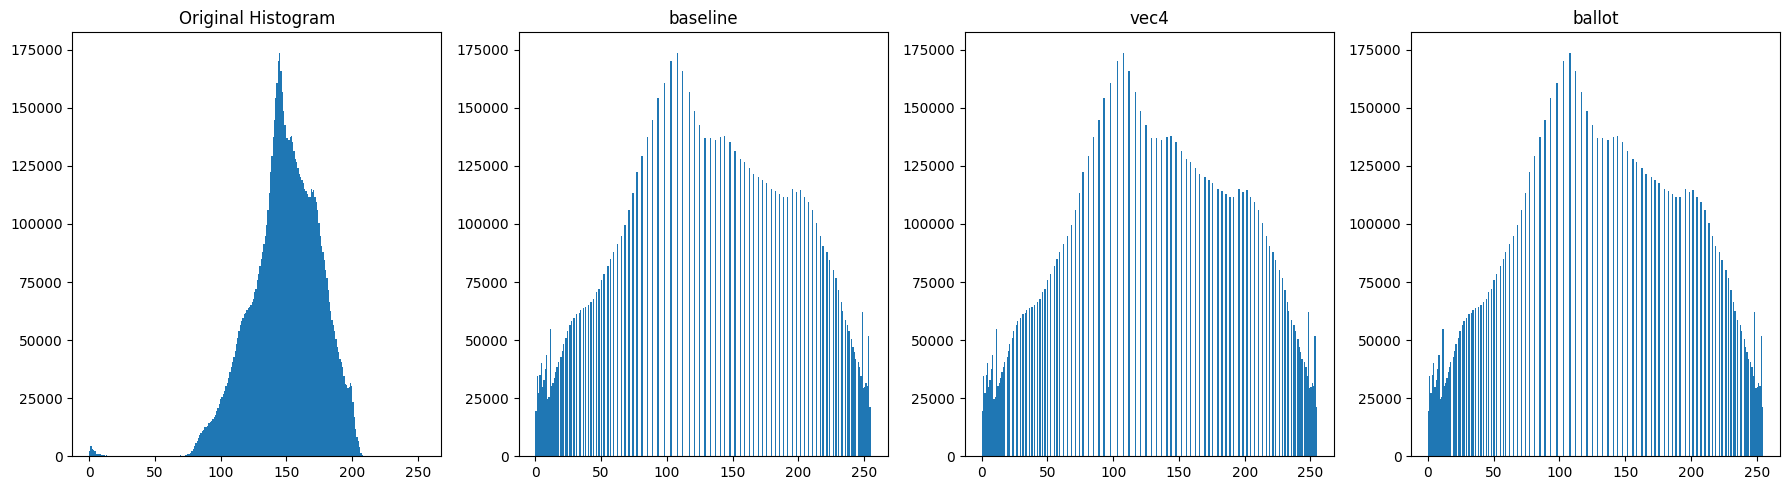


IMG_0811.JPG
baseline        time = 0.254 ms
vec4            time = 0.162 ms
ballot          time = 0.175 ms


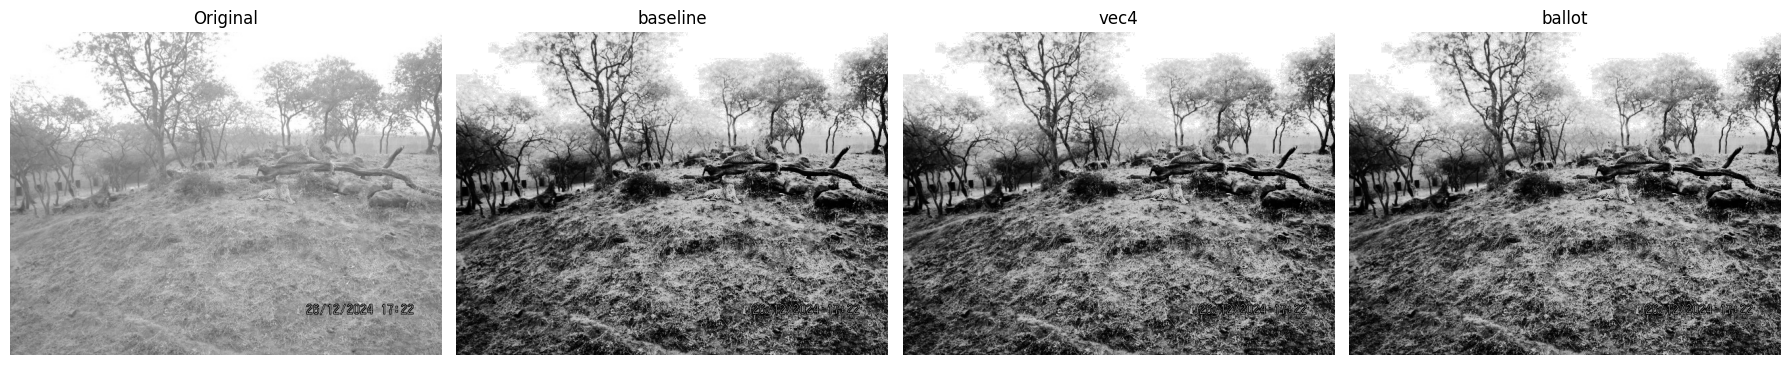

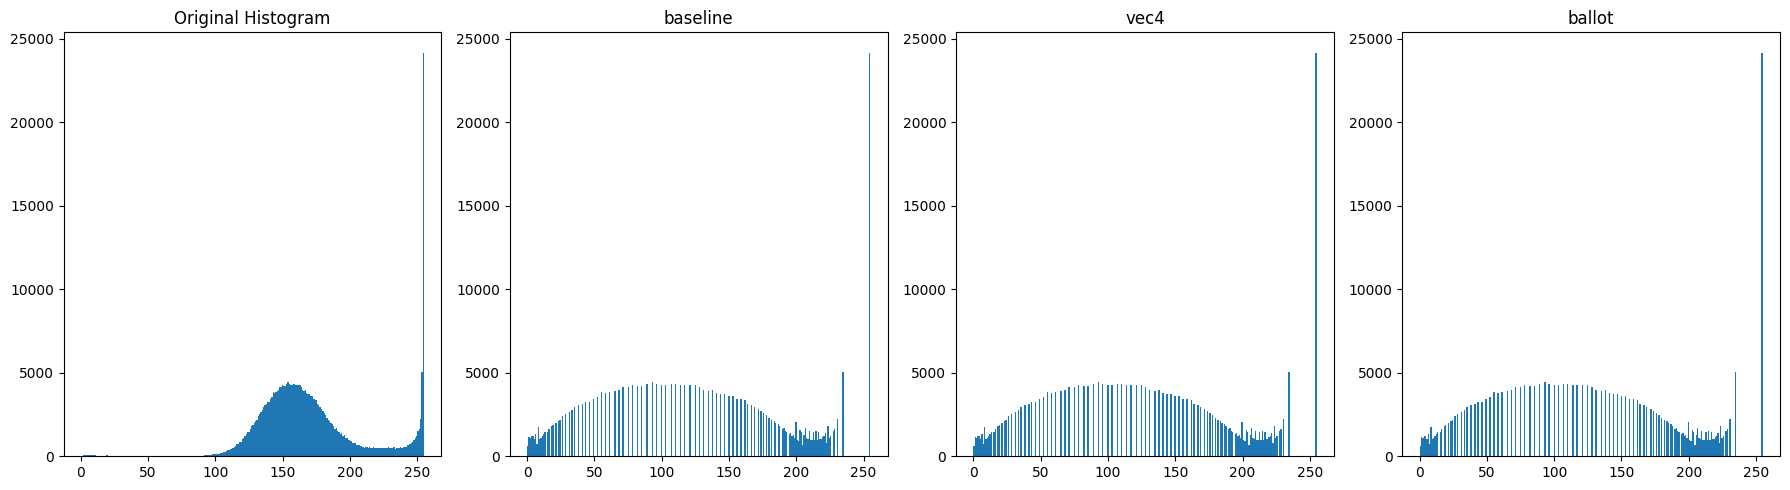

In [26]:
from PIL import Image
import cupy as cp
import numpy as np
import os
import time

module_single = cp.RawModule(code=cuda_source)
hist_baseline_kernel   = module_single.get_function("histogram_baseline")
hist_vec4_kernel   = module_single.get_function("histogram_vec4")
hist_ballot_kernel   = module_single.get_function("histogram_ballot")
scan_kernel   = module_single.get_function("kogge_stone_scan")
lut_kernel    = module_single.get_function("lut_apply_textbook")

IMAGE_DIR = "/kaggle/input/datasets/tomatopdf/hist-eql-dataset/"

image_files = [
    os.path.join(IMAGE_DIR, f)
    for f in os.listdir(IMAGE_DIR)
    if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp"))
]

kernels = [
    ("baseline", hist_baseline_kernel),
    ("vec4",     hist_vec4_kernel),
    ("ballot",   hist_ballot_kernel),
]

import matplotlib.pyplot as plt

for image_path in image_files:

    print("\n===================================================")
    print(os.path.basename(image_path))

    img = Image.open(image_path).convert("L")
    img_np = np.array(img, dtype=np.uint8)

    H, W = img_np.shape
    n_pixels = H * W

    img_d = cp.asarray(img_np.ravel())

    T = 256
    B = (n_pixels + T - 1) // T

    # --------------------------------------------------
    # image figure
    # --------------------------------------------------

    fig_img, ax_img = plt.subplots(1, 4, figsize=(18, 5))

    ax_img[0].imshow(img_np, cmap="gray", vmin=0, vmax=255)
    ax_img[0].set_title("Original")
    ax_img[0].axis("off")

    # --------------------------------------------------
    # histogram figure
    # --------------------------------------------------

    fig_hist, ax_hist = plt.subplots(1, 4, figsize=(18, 5))

    ax_hist[0].hist(img_np.ravel(), bins=256, range=(0,255))
    ax_hist[0].set_title("Original Histogram")

    # --------------------------------------------------
    # kernels
    # --------------------------------------------------

    for idx, (name, hist_kernel) in enumerate(kernels, start=1):

        hist_d = cp.zeros(256, dtype=cp.uint32)
        cdf_d  = cp.zeros(256, dtype=cp.float32)
        out_d  = cp.zeros(n_pixels, dtype=cp.uint8)

        # warmup
        hist_kernel((B,), (T,), (img_d, hist_d, n_pixels))
        cp.cuda.Stream.null.synchronize()

        hist_d.fill(0)

        t0 = cp.cuda.Event()
        t1 = cp.cuda.Event()

        t0.record()

        hist_kernel((B,), (T,), (img_d, hist_d, n_pixels))
        scan_kernel((1,), (256,), (hist_d, cdf_d, n_pixels))

        cp.cuda.Stream.null.synchronize()

        cdf_np = cp.asnumpy(cdf_d)
        cdf_min = np.float32(cdf_np[cdf_np > 0][0])

        lut_kernel((B,), (T,), (img_d, out_d, cdf_d, cdf_min, n_pixels))

        t1.record()
        t1.synchronize()

        elapsed_ms = cp.cuda.get_elapsed_time(t0, t1)

        out_img = cp.asnumpy(out_d).reshape(H, W)

        print(f"{name:15s} time = {elapsed_ms:.3f} ms")

        # image column
        ax_img[idx].imshow(out_img, cmap="gray", vmin=0, vmax=255)
        ax_img[idx].set_title(name)
        ax_img[idx].axis("off")

        # histogram column
        ax_hist[idx].hist(out_img.ravel(), bins=256, range=(0,255))
        ax_hist[idx].set_title(name)

    fig_img.tight_layout()
    fig_hist.tight_layout()

    plt.show()
        